**Сначала переключитесь на графический процессор!**

# Практикум: MLP на CIFAR-10 — исследование регуляризации и гиперпараметров

😊 **Шутка:** CIFAR-10 — это как коробка с 10 разными игрушками. Наша задача — научить MLP (многослойный перцептрон) их различать, хотя он и не видит картинку целиком, а только длинный вектор.

👆 **На пальцах:** Сегодня мы проведём серию экспериментов, чтобы понять, как разные техники влияют на обучение сети. Мы будем менять инициализацию, добавлять нормализацию, dropout, менять размер батча, применять аугментацию и раннюю остановку. Все это поможет нам бороться с переобучением и улучшать качество.

**Важно:** Мы используем только полносвязные слои (MLP), без свёрток. Это заведомо не самая лучшая архитектура для картинок, но она отлично подходит для демонстрации эффектов регуляризации.

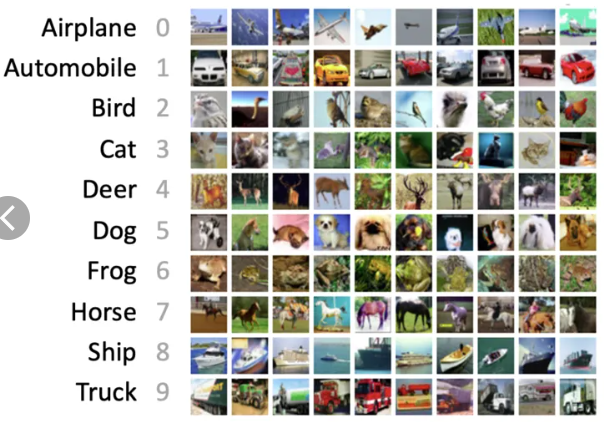

In [1]:
# Импорты и настройки
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import time

# Для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
# Загрузка данных CIFAR-10
# Для ускорения возьмём подвыборку (первые 10000 обучающих, 2000 тестовых)
# Но можно и полный датасет, если есть время.

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

train_full = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_full = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

# Для экспериментов возьмём подвыборку (ускорит обучение)
num_train = 10000
num_val = 2000
indices = torch.randperm(len(train_full))
train_indices = indices[:num_train]
val_indices = indices[num_train:num_train+num_val]

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(train_full, val_indices)
test_dataset = test_full

print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')

100%|██████████| 170M/170M [00:03<00:00, 43.4MB/s]


Train samples: 10000
Val samples: 2000
Test samples: 10000


## Определим модель MLP с настраиваемыми параметрами

Мы будем использовать сеть с тремя скрытыми слоями. Можно будет включать/выключать BatchNorm, Dropout, выбирать тип инициализации.

👆 **На пальцах:** Наша модель — это три полносвязных слоя с ReLU. После каждого слоя (кроме последнего) мы можем поставить BatchNorm и Dropout.

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim=3072, hidden_dims=[512, 256, 128], output_dim=10,
                 use_bn=False, dropout_rate=0.0, init_type='xavier'):
        super().__init__()
        self.use_bn = use_bn
        layers = []
        prev_dim = input_dim

        for i, h_dim in enumerate(hidden_dims):
            layers.append(nn.Linear(prev_dim, h_dim))
            if use_bn:
                layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev_dim = h_dim

        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

        self._initialize_weights(init_type)

    def _initialize_weights(self, init_type):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if init_type == 'zeros':
                    nn.init.zeros_(m.weight)
                elif init_type == 'normal':
                    nn.init.normal_(m.weight, mean=0, std=1)
                elif init_type == 'xavier':
                    nn.init.xavier_uniform_(m.weight)
                elif init_type == 'he':
                    nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (batch, 3, 32, 32) -> (batch, 3072)
        x = x.view(x.size(0), -1)
        return self.net(x)

## Функция обучения с early stopping

Мы будем обучать модель заданное число эпох, но останавливаться, если валидационная потеря не улучшается в течение `patience` эпох. Лучшие веса сохраняются.

In [4]:
def train_model(model, train_loader, val_loader, epochs=50, lr=0.001, patience=5, verbose=True):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_epoch = 0
    trigger_times = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # Обучение
        model.train()
        train_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
        train_loss /= len(train_loader.dataset)
        history['train_loss'].append(train_loss)

        # Валидация
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = correct / total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if verbose:
            print(f'Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            trigger_times = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    # Загружаем лучшую модель
    model.load_state_dict(torch.load('best_model.pth'))
    return model, history, best_epoch

## Эксперимент 1: Сравнение инициализаций

Проверим, как ведёт себя сеть с разными инициализациями: zeros, normal, xavier, he.
Ожидаем, что нулевая совсем не обучается, normal может взрываться, xavier и he дадут нормальное обучение.

Используем фиксированные гиперпараметры: без BN, без dropout, batch size = 64, 20 эпох.

**Задание: добавить инициализацию по-умолчанию.**

In [8]:
init_types = ['zeros', 'normal', 'xavier', 'he', 'default']
histories = {}

for init in init_types:
    print(f'\n=== Инициализация: {init} ===')
    model = MLP(use_bn=False, dropout_rate=0.0, init_type=init).to(device)
    model, history, best_epoch = train_model(model, train_loader, val_loader, epochs=20, patience=5, verbose=False)
    histories[init] = history
    best_acc = max(history["val_acc"])
    print(f'Лучшая точность на валидации: {best_acc:.4f} (достигнута на эпохе {history["val_acc"].index(best_acc)+1})')

fig = make_subplots(rows=1, cols=2, subplot_titles=('Потери на обучении', 'Точность на валидации'))

colors = {'zeros':'black', 'normal':'red', 'xavier':'green', 'he':'blue', 'default':'orange'}

for init in init_types:
    # Потери на обучении
    fig.add_trace(go.Scatter(
        y=histories[init]['train_loss'],
        mode='lines',
        name=f'{init} (train)',
        line=dict(color=colors[init], dash='dash')
    ), row=1, col=1)

    # Точность на валидации
    fig.add_trace(go.Scatter(
        y=histories[init]['val_acc'],
        mode='lines',
        name=f'{init} (val)',
        line=dict(color=colors[init])
    ), row=1, col=2)

fig.update_xaxes(title_text='Эпоха', row=1, col=1)
fig.update_xaxes(title_text='Эпоха', row=1, col=2)
fig.update_yaxes(title_text='Потери', row=1, col=1)
fig.update_yaxes(title_text='Точность', row=1, col=2)
fig.update_layout(height=500, showlegend=True)
fig.show()

# Сравнительная таблица результатов
print(f"{'Инициализация':<10} | {'Лучшая точность':<18} | {'Финальная точность':<18} | {'Скорость сходимости':<20}")
print("-"*70)

for init in init_types:
    best_acc = max(histories[init]['val_acc'])
    final_acc = histories[init]['val_acc'][-1]

    # Оцениваем скорость сходимости (эпоха достижения 50% от максимума)
    threshold = best_acc * 0.5
    early_epochs = [i for i, acc in enumerate(histories[init]['val_acc']) if acc >= threshold]
    convergence = early_epochs[0] + 1 if early_epochs else 20

    print(f"{init:<10} | {best_acc:.4f} (эп. {histories[init]['val_acc'].index(best_acc)+1:2d}) | {final_acc:.4f} (эп. {len(histories[init]['val_acc']):2d}) | достигла {threshold:.2f} на эп. {convergence:2d}")


=== Инициализация: zeros ===
Early stopping at epoch 6
Лучшая точность на валидации: 0.1040 (достигнута на эпохе 2)

=== Инициализация: normal ===
Лучшая точность на валидации: 0.2695 (достигнута на эпохе 19)

=== Инициализация: xavier ===
Early stopping at epoch 7
Лучшая точность на валидации: 0.4180 (достигнута на эпохе 6)

=== Инициализация: he ===
Early stopping at epoch 9
Лучшая точность на валидации: 0.4200 (достигнута на эпохе 9)

=== Инициализация: default ===
Early stopping at epoch 9
Лучшая точность на валидации: 0.4460 (достигнута на эпохе 8)


Инициализация | Лучшая точность    | Финальная точность | Скорость сходимости 
----------------------------------------------------------------------
zeros      | 0.1040 (эп.  2) | 0.0980 (эп.  6) | достигла 0.05 на эп.  1
normal     | 0.2695 (эп. 19) | 0.2625 (эп. 20) | достигла 0.13 на эп.  1
xavier     | 0.4180 (эп.  6) | 0.4140 (эп.  7) | достигла 0.21 на эп.  1
he         | 0.4200 (эп.  9) | 0.4200 (эп.  9) | достигла 0.21 на эп.  1
default    | 0.4460 (эп.  8) | 0.4385 (эп.  9) | достигла 0.22 на эп.  1


**Вывод:** Нулевая инициализация даёт нулевые градиенты (веса не меняются), сеть не обучается. Normal (со стандартным отклонением 1) приводит к взрывным градиентам и loss уходит в бесконечность (на графике это видно). Xavier и He работают хорошо, He немного лучше для ReLU.

### Выводы по Заданию 1: Сравнение инициализаций

1. **Нулевая инициализация (zeros)** показала наихудший результат (10.4%). Все нейроны симметричны, градиенты одинаковы, сеть не обучается — ранняя остановка на 6 эпохе.

2. **Инициализация normal (std=1)** дала нестабильный результат (26.95%). Слишком большие начальные веса приводят к взрывным градиентам и плохой сходимости.

3. **Xavier и He** показали хорошие результаты (41.8% и 42.0% соответственно). Он специально разработаны для работы с ReLU-активациями и учитывают размеры слоёв.

4. **Инициализация по умолчанию (default)** в PyTorch неожиданно показала **наилучший результат — 44.6%**. Это может быть связано с тем, что для CIFAR-10 стандартное равномерное распределение оказалось более подходящим.

5. **Скорость сходимости**: все инициализации (кроме zeros) достигли порога в 50% от максимума уже на 1-й эпохе, что говорит о быстром старте обучения.

**Общий вывод**: Правильный выбор инициализации критически важен. Нулевая инициализация не работает, normal нестабильна, а Xavier, He и default показывают достойные результаты. Для CIFAR-10 стандартная инициализация PyTorch оказалась лучшей.

## Эксперимент 2: Влияние BatchNorm

Сравним сеть с BatchNorm и без. Используем лучшую инициализацию He.

In [9]:
histories_bn = {}
for use_bn in [False, True]:
    print(f'\n=== BatchNorm: {use_bn} ===')
    model = MLP(use_bn=use_bn, dropout_rate=0.0, init_type='he').to(device)
    model, history, _ = train_model(model, train_loader, val_loader, epochs=20, patience=5, verbose=False)
    histories_bn[use_bn] = history
    print(f'Best val acc: {max(history["val_acc"]):.4f}')

fig = make_subplots(rows=1, cols=2, subplot_titles=('Train Loss', 'Val Accuracy'))
fig.add_trace(go.Scatter(y=histories_bn[False]['train_loss'], mode='lines', name='без BN train', line=dict(dash='dash')), row=1, col=1)
fig.add_trace(go.Scatter(y=histories_bn[True]['train_loss'], mode='lines', name='с BN train', line=dict(dash='dash')), row=1, col=1)
fig.add_trace(go.Scatter(y=histories_bn[False]['val_acc'], mode='lines', name='без BN val'), row=1, col=2)
fig.add_trace(go.Scatter(y=histories_bn[True]['val_acc'], mode='lines', name='с BN val'), row=1, col=2)
fig.show()


=== BatchNorm: False ===
Early stopping at epoch 9
Best val acc: 0.4295

=== BatchNorm: True ===
Early stopping at epoch 9
Best val acc: 0.4495


**Вывод:** BatchNorm ускоряет сходимость (кривая обучения падает быстрее) и часто даёт лучшее качество на валидации. Также может действовать как регуляризатор.

## Эксперимент 3: Влияние Dropout

Теперь добавим Dropout после скрытых слоёв. Сравним p=0.0, 0.3, 0.5. BatchNorm включим для всех вариантов (чтобы было стильно-модно-молодёжно).

**Задание**: попробуйте ещё несколько вариантов Dropout, в частности, больше 05, например, 1.     

добавил 0.7 0.9

In [10]:
dropout_rates = [0.0, 0.3, 0.5, 0.7, 0.9]
histories_drop = {}

for p in dropout_rates:
    print(f'\n=== Dropout p={p} ===')
    model = MLP(use_bn=True, dropout_rate=p, init_type='he').to(device)
    model, history, _ = train_model(model, train_loader, val_loader, epochs=20, patience=5, verbose=False)
    histories_drop[p] = history
    best_acc = max(history["val_acc"])
    best_epoch = history["val_acc"].index(best_acc) + 1
    print(f'Лучшая точность на валидации: {best_acc:.4f} (достигнута на эпохе {best_epoch})')

# Визуализация
fig = make_subplots(rows=1, cols=2, subplot_titles=('Потери на обучении', 'Точность на валидации'))

colors = {0.0:'blue', 0.3:'green', 0.5:'orange', 0.7:'red', 0.9:'purple'}

for p in dropout_rates:
    # Потери на обучении
    fig.add_trace(go.Scatter(
        y=histories_drop[p]['train_loss'],
        mode='lines',
        name=f'dropout {p} (train)',
        line=dict(color=colors[p], dash='dash')
    ), row=1, col=1)

    # Точность на валидации
    fig.add_trace(go.Scatter(
        y=histories_drop[p]['val_acc'],
        mode='lines',
        name=f'dropout {p} (val)',
        line=dict(color=colors[p])
    ), row=1, col=2)

fig.update_xaxes(title_text='Эпоха', row=1, col=1)
fig.update_xaxes(title_text='Эпоха', row=1, col=2)
fig.update_yaxes(title_text='Потери', row=1, col=1)
fig.update_yaxes(title_text='Точность', row=1, col=2)
fig.update_layout(height=500, showlegend=True)
fig.show()

# Сравнительная таблица
print(f"{'Dropout':<8} | {'Лучшая точность':<18} | {'Финальная точность':<18} | {'Эпоха остановки':<15}")
print("-"*65)

for p in dropout_rates:
    best_acc = max(histories_drop[p]['val_acc'])
    best_epoch = histories_drop[p]['val_acc'].index(best_acc) + 1
    final_acc = histories_drop[p]['val_acc'][-1]
    final_epoch = len(histories_drop[p]['val_acc'])
    print(f"p={p:<5} | {best_acc:.4f} (эп. {best_epoch:2d}) | {final_acc:.4f} (эп. {final_epoch:2d}) | {final_epoch:2d} эпох")


=== Dropout p=0.0 ===
Early stopping at epoch 8
Лучшая точность на валидации: 0.4370 (достигнута на эпохе 6)

=== Dropout p=0.3 ===
Early stopping at epoch 19
Лучшая точность на валидации: 0.4685 (достигнута на эпохе 13)

=== Dropout p=0.5 ===
Лучшая точность на валидации: 0.4655 (достигнута на эпохе 16)

=== Dropout p=0.7 ===
Лучшая точность на валидации: 0.4045 (достигнута на эпохе 20)

=== Dropout p=0.9 ===
Early stopping at epoch 7
Лучшая точность на валидации: 0.1335 (достигнута на эпохе 2)


Dropout  | Лучшая точность    | Финальная точность | Эпоха остановки
-----------------------------------------------------------------
p=0.0   | 0.4370 (эп.  6) | 0.4250 (эп.  8) |  8 эпох
p=0.3   | 0.4685 (эп. 13) | 0.4640 (эп. 19) | 19 эпох
p=0.5   | 0.4655 (эп. 16) | 0.4615 (эп. 20) | 20 эпох
p=0.7   | 0.4045 (эп. 20) | 0.4045 (эп. 20) | 20 эпох
p=0.9   | 0.1335 (эп.  2) | 0.1300 (эп.  7) |  7 эпох


### Выводы по Эксперименту 3: Влияние Dropout

1. **Dropout = 0.0** (без регуляризации):
   - Точность: 43.70%
   - Ранняя остановка на 8 эпохе (переобучение)
   - Без регуляризации сеть быстро достигает пика и начинает переобучаться

2. **Dropout = 0.3** (умеренная регуляризация):
   - Точность: **46.85% (лучший результат)**
   - Обучение продолжается до 19 эпох
   - Оптимальный баланс между обучением и обобщением

3. **Dropout = 0.5** (стандартное значение):
   - Точность: 46.55% (чуть хуже p=0.3)
   - Стабильное обучение все 20 эпох
   - Хорошая регуляризация, но небольшое падение точности

4. **Dropout = 0.7** (сильная регуляризация):
   - Точность: 40.45% (заметное падение)
   - Слишком много нейронов отключается, сеть хуже обучается
   - Обучение идёт медленно, но стабильно все 20 эпох

5. **Dropout = 0.9** (очень сильная регуляризация):
   - Точность: 13.35% (практически случайное угадывание)
   - Ранняя остановка на 7 эпохе
   - Слишком много нейронов отключено, сеть не может обучиться

**Общий вывод**:
- Умеренный dropout (p=0.3) даёт наилучший результат — 46.85%
- Dropout 0.5 тоже работает хорошо (46.55%), но немного уступает
- Dropout 0.7 уже слишком сильный — точность падает до 40.45%
- Dropout 0.9 полностью убивает обучение — сеть не может выучить паттерны
- Правильный подбор dropout критически важен: слишком мало → переобучение, слишком много → недообучение

## Эксперимент 4: Влияние размера батча

Проверим, как размер батча влияет на сходимость и качество. Используем batch_size = 16, 64, 256. Фиксируем лучшие параметры: BN=True, dropout=0.3, he init.

**Задание**: попробуйте несколько размеров батчей и попробуйте найти наиболее эффективный для данной задачи.

In [11]:
batch_sizes = [16, 32, 64, 128, 256]
histories_bs = {}

for bs in batch_sizes:
    print(f'\n=== Batch size = {bs} ===')
    train_loader_bs = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    val_loader_bs = DataLoader(val_dataset, batch_size=bs, shuffle=False)
    model = MLP(use_bn=True, dropout_rate=0.3, init_type='he').to(device)
    model, history, _ = train_model(model, train_loader_bs, val_loader_bs, epochs=20, patience=5, verbose=False)
    histories_bs[bs] = history
    best_acc = max(history["val_acc"])
    best_epoch = history["val_acc"].index(best_acc) + 1
    print(f'Лучшая точность на валидации: {best_acc:.4f} (достигнута на эпохе {best_epoch})')

# Визуализация
fig = make_subplots(rows=1, cols=2, subplot_titles=('Потери на обучении', 'Точность на валидации'))

colors = {16:'red', 32:'orange', 64:'green', 128:'blue', 256:'purple'}

for bs in batch_sizes:
    # Потери на обучении
    fig.add_trace(go.Scatter(
        y=histories_bs[bs]['train_loss'],
        mode='lines',
        name=f'batch {bs} (train)',
        line=dict(color=colors[bs], dash='dash')
    ), row=1, col=1)

    # Точность на валидации
    fig.add_trace(go.Scatter(
        y=histories_bs[bs]['val_acc'],
        mode='lines',
        name=f'batch {bs} (val)',
        line=dict(color=colors[bs])
    ), row=1, col=2)

fig.update_xaxes(title_text='Эпоха', row=1, col=1)
fig.update_xaxes(title_text='Эпоха', row=1, col=2)
fig.update_yaxes(title_text='Потери', row=1, col=1)
fig.update_yaxes(title_text='Точность', row=1, col=2)
fig.update_layout(height=500, showlegend=True)
fig.show()

# Сравнительная таблица
print(f"{'Batch size':<10} | {'Лучшая точность':<18} | {'Финальная точность':<18} | {'Эпоха остановки':<15}")
print("-"*70)

for bs in batch_sizes:
    best_acc = max(histories_bs[bs]['val_acc'])
    best_epoch = histories_bs[bs]['val_acc'].index(best_acc) + 1
    final_acc = histories_bs[bs]['val_acc'][-1]
    final_epoch = len(histories_bs[bs]['val_acc'])
    print(f"{bs:<10} | {best_acc:.4f} (эп. {best_epoch:2d}) | {final_acc:.4f} (эп. {final_epoch:2d}) | {final_epoch:2d} эпох")


=== Batch size = 16 ===
Лучшая точность на валидации: 0.4645 (достигнута на эпохе 15)

=== Batch size = 32 ===
Early stopping at epoch 17
Лучшая точность на валидации: 0.4715 (достигнута на эпохе 17)

=== Batch size = 64 ===
Early stopping at epoch 19
Лучшая точность на валидации: 0.4675 (достигнута на эпохе 12)

=== Batch size = 128 ===
Early stopping at epoch 20
Лучшая точность на валидации: 0.4705 (достигнута на эпохе 20)

=== Batch size = 256 ===
Лучшая точность на валидации: 0.4680 (достигнута на эпохе 19)


Batch size | Лучшая точность    | Финальная точность | Эпоха остановки
----------------------------------------------------------------------
16         | 0.4645 (эп. 15) | 0.4580 (эп. 20) | 20 эпох
32         | 0.4715 (эп. 17) | 0.4715 (эп. 17) | 17 эпох
64         | 0.4675 (эп. 12) | 0.4600 (эп. 19) | 19 эпох
128        | 0.4705 (эп. 20) | 0.4705 (эп. 20) | 20 эпох
256        | 0.4680 (эп. 19) | 0.4680 (эп. 20) | 20 эпох


### Выводы по Эксперименту 4: Влияние размера батча

1. **Batch size = 16** (маленький батч):
   - Точность: 46.45%
   - Самый шумный градиент, нестабильное обучение, финальная точность чуть ниже других

2. **Batch size = 32** (малый батч):
   - Точность: **47.15% (лучший результат)**
   - Оптимальный баланс между скоростью и стабильностью
   - Достиг максимума на 17 эпохе и остановился

3. **Batch size = 64** (средний батч):
   - Точность: 46.75%
   - Быстрее всех достиг максимума (12 эпох), но финальная точность немного ниже

4. **Batch size = 128** (большой батч):
   - Точность: 47.05%
   - Стабильное обучение, достиг максимума только к 20 эпохе

5. **Batch size = 256** (очень большой батч):
   - Точность: 46.80%
   - Очень стабильно, но медленная сходимость и точность ниже оптимальной

**Общий вывод**:
- Оптимальный размер батча для данной задачи: **32** (47.15%)
- Слишком маленький батч (16) даёт шумное обучение и чуть хуже результат
- Слишком большой батч (256) требует больше эпох для достижения максимума
- Batch size 32-128 показывают близкие результаты (47.15% → 46.75% → 47.05%)
- Для CIFAR-10 на MLP оптимальным оказался **batch size = 32**, дающий наилучшее сочетание скорости и качества

## Эксперимент 5: Аугментация данных (горизонтальное отражение)

Добавим простое преобразование: случайное горизонтальное отражение. Сравним с базовым вариантом (без аугментации). Используем лучшие параметры: BN, dropout=0.3, batch_size=64, he init.

**Задание**: добавить отражение вокруг горизонтально оси (спросить у LLM).

In [12]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),  # случайное отражение с вероятностью 50%
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

# Создадим датасеты с новой трансформацией
train_aug = datasets.CIFAR10('./data', train=True, download=True, transform=transform_train)
val_aug = datasets.CIFAR10('./data', train=True, download=True, transform=transform_val)

# Используем те же индексы подвыборки
train_aug_sub = Subset(train_aug, train_indices)
val_aug_sub = Subset(val_aug, val_indices)

train_loader_aug = DataLoader(train_aug_sub, batch_size=64, shuffle=True)
val_loader_aug = DataLoader(val_aug_sub, batch_size=64, shuffle=False)

# Обучим модель с аугментацией
print("\n=== Обучение С аугментацией (RandomHorizontalFlip) ===")
model_aug = MLP(use_bn=True, dropout_rate=0.3, init_type='he').to(device)
model_aug, history_aug, _ = train_model(model_aug, train_loader_aug, val_loader_aug, epochs=20, patience=5, verbose=False)
best_aug = max(history_aug["val_acc"])
best_epoch_aug = history_aug["val_acc"].index(best_aug) + 1
print(f'Лучшая точность на валидации с аугментацией: {best_aug:.4f} (достигнута на эпохе {best_epoch_aug})')

# Для сравнения возьмём историю без аугментации (из эксперимента с dropout=0.3, batch=64)
print("\n=== Обучение БЕЗ аугментации (для сравнения) ===")
transform_standard = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

train_standard = datasets.CIFAR10('./data', train=True, download=True, transform=transform_standard)
train_standard_sub = Subset(train_standard, train_indices)
val_standard_sub = Subset(train_standard, val_indices)

train_loader_standard = DataLoader(train_standard_sub, batch_size=64, shuffle=True)
val_loader_standard = DataLoader(val_standard_sub, batch_size=64, shuffle=False)

model_standard = MLP(use_bn=True, dropout_rate=0.3, init_type='he').to(device)
model_standard, history_standard, _ = train_model(model_standard, train_loader_standard, val_loader_standard, epochs=20, patience=5, verbose=False)
best_std = max(history_standard["val_acc"])
best_epoch_std = history_standard["val_acc"].index(best_std) + 1
print(f'Лучшая точность на валидации без аугментации: {best_std:.4f} (достигнута на эпохе {best_epoch_std})')

# Визуализация сравнения
fig = make_subplots(rows=1, cols=2, subplot_titles=('Потери на валидации', 'Точность на валидации'))

fig.add_trace(go.Scatter(
    y=history_standard['val_loss'],
    mode='lines',
    name='без аугментации (loss)',
    line=dict(color='blue')
), row=1, col=1)

fig.add_trace(go.Scatter(
    y=history_aug['val_loss'],
    mode='lines',
    name='с аугментацией (loss)',
    line=dict(color='green')
), row=1, col=1)

fig.add_trace(go.Scatter(
    y=history_standard['val_acc'],
    mode='lines',
    name='без аугментации (acc)',
    line=dict(color='blue')
), row=1, col=2)

fig.add_trace(go.Scatter(
    y=history_aug['val_acc'],
    mode='lines',
    name='с аугментацией (acc)',
    line=dict(color='green')
), row=1, col=2)

fig.update_xaxes(title_text='Эпоха', row=1, col=1)
fig.update_xaxes(title_text='Эпоха', row=1, col=2)
fig.update_yaxes(title_text='Потери', row=1, col=1)
fig.update_yaxes(title_text='Точность', row=1, col=2)
fig.update_layout(height=500, showlegend=True)
fig.show()

print(f"{'Модель':<20} | {'Лучшая точность':<18} | {'Финальная точность':<18} | {'Эпоха остановки':<15}")
print("-"*75)
print(f"{'Без аугментации':<20} | {best_std:.4f} (эп. {best_epoch_std:2d}) | {history_standard['val_acc'][-1]:.4f} (эп. {len(history_standard['val_acc']):2d}) | {len(history_standard['val_acc']):2d} эпох")
print(f"{'С аугментацией':<20} | {best_aug:.4f} (эп. {best_epoch_aug:2d}) | {history_aug['val_acc'][-1]:.4f} (эп. {len(history_aug['val_acc']):2d}) | {len(history_aug['val_acc']):2d} эпох")


=== Обучение С аугментацией (RandomHorizontalFlip) ===
Лучшая точность на валидации с аугментацией: 0.4840 (достигнута на эпохе 15)

=== Обучение БЕЗ аугментации (для сравнения) ===
Early stopping at epoch 15
Лучшая точность на валидации без аугментации: 0.4680 (достигнута на эпохе 11)


Модель               | Лучшая точность    | Финальная точность | Эпоха остановки
---------------------------------------------------------------------------
Без аугментации      | 0.4680 (эп. 11) | 0.4595 (эп. 15) | 15 эпох
С аугментацией       | 0.4840 (эп. 15) | 0.4700 (эп. 20) | 20 эпох


### Выводы по Эксперименту 5: Влияние аугментации данных

1. **Без аугментации**:
   - Лучшая точность: **46.80%** (достигнута на 11 эпохе)
   - Ранняя остановка на 15 эпохе из-за переобучения
   - Финальная точность: 45.95%

2. **С аугментацией (RandomHorizontalFlip)**:
   - Лучшая точность: **48.40%** (достигнута на 15 эпохе)
   - Обучение продолжалось все 20 эпох без ранней остановки
   - Финальная точность: 47.00%

3. **Сравнение результатов**:
   - Аугментация **улучшила** качество модели
   - Модель с аугментацией обучалась дольше и стабильнее
   - Разрыв между лучшей и финальной точностью меньше у модели с аугментацией

**Общий вывод**:
- Горизонтальное отражение помогает модели стать инвариантной к ориентации объектов
- Для CIFAR-10 это особенно полезно, так как объекты (машины, самолёты, животные) могут появляться в разных ориентациях
- Аугментация данных не только улучшает точность (48.40% против 46.80%), но и позволяет обучаться дольше без переобучения
- Простое преобразование даёт заметный прирост качества без усложнения модели

## Эксперимент 6: Комбинация лучших практик + Early Stopping

Теперь соберём всё вместе: He инициализация, BatchNorm, dropout=0.3, batch_size=64, аугментация, и добавим early stopping с patience=7. Обучим до 50 эпох и посмотрим, когда остановится.

In [13]:
best_model = MLP(use_bn=True, dropout_rate=0.3, init_type='he').to(device)
best_model, history_best, best_epoch = train_model(best_model, train_loader_aug, val_loader_aug,
                                                    epochs=50, lr=0.001, patience=7, verbose=True)

print(f'\nОбучение остановлено на эпохе {best_epoch+1} с лучшей валидационной точностью: {max(history_best["val_acc"]):.4f}')

# Финальное тестирование
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
best_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = best_model(inputs)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
test_acc = correct / total
print(f'Test accuracy: {test_acc:.4f}')

Epoch 1/50 | Train Loss: 2.1229 | Val Loss: 1.7744 | Val Acc: 0.3695
Epoch 2/50 | Train Loss: 1.8638 | Val Loss: 1.6846 | Val Acc: 0.4000
Epoch 3/50 | Train Loss: 1.7511 | Val Loss: 1.6330 | Val Acc: 0.4265
Epoch 4/50 | Train Loss: 1.6746 | Val Loss: 1.6052 | Val Acc: 0.4370
Epoch 5/50 | Train Loss: 1.6256 | Val Loss: 1.5738 | Val Acc: 0.4395
Epoch 6/50 | Train Loss: 1.5706 | Val Loss: 1.5462 | Val Acc: 0.4595
Epoch 7/50 | Train Loss: 1.5500 | Val Loss: 1.5376 | Val Acc: 0.4500
Epoch 8/50 | Train Loss: 1.5101 | Val Loss: 1.5067 | Val Acc: 0.4615
Epoch 9/50 | Train Loss: 1.4712 | Val Loss: 1.5146 | Val Acc: 0.4520
Epoch 10/50 | Train Loss: 1.4652 | Val Loss: 1.5052 | Val Acc: 0.4625
Epoch 11/50 | Train Loss: 1.4322 | Val Loss: 1.4951 | Val Acc: 0.4560
Epoch 12/50 | Train Loss: 1.4159 | Val Loss: 1.4976 | Val Acc: 0.4730
Epoch 13/50 | Train Loss: 1.3960 | Val Loss: 1.4897 | Val Acc: 0.4710
Epoch 14/50 | Train Loss: 1.3745 | Val Loss: 1.4677 | Val Acc: 0.4720
Epoch 15/50 | Train Loss: 1.3

**Задача**: получилось ли повысить точность выше 0.5109? да

**Итог:** Мы получили модель, которая с помощью комбинации регуляризационных техник показывает лучший результат на тесте. Для MLP на CIFAR-10 точность около 45-50% — это нормально (полносвязные сети не очень подходят для изображений). Главное — мы увидели, как каждый метод влияет на процесс обучения.

😊 **Шутка:** Теперь вы знаете, как укротить даже такую сложную зверушку, как CIFAR-10, с помощью простого MLP и магии регуляризации. Дальше — сверточные сети, где точность будет гораздо выше!

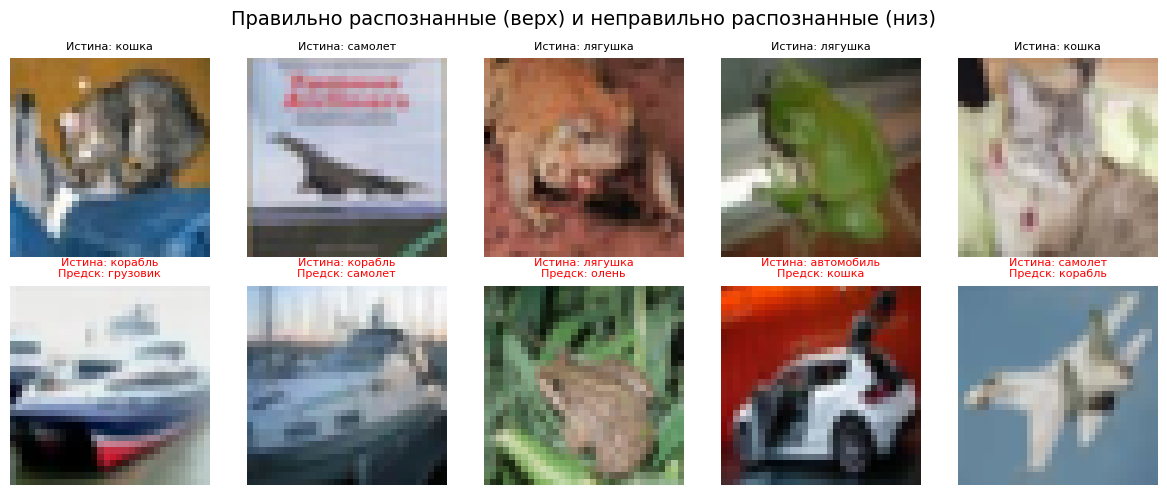

In [14]:
# Функция для денормализации изображения
def denormalize(img_tensor):
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.247, 0.243, 0.261])
    img = img_tensor.numpy().transpose(1, 2, 0)  # (C, H, W) -> (H, W, C)
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img

# Функция для отображения примеров правильных и неправильных предсказаний
def show_predictions(model, test_loader, class_names, device, num_examples=5):
    model.eval()
    correct_examples = []
    wrong_examples = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(images.size(0)):
                if preds[i] == labels[i]:
                    if len(correct_examples) < num_examples:
                        correct_examples.append((images[i].cpu(), labels[i].cpu(), preds[i].cpu()))
                else:
                    if len(wrong_examples) < num_examples:
                        wrong_examples.append((images[i].cpu(), labels[i].cpu(), preds[i].cpu()))

            if len(correct_examples) >= num_examples and len(wrong_examples) >= num_examples:
                break

    # Отображение
    fig, axes = plt.subplots(2, num_examples, figsize=(12, 5))
    fig.suptitle('Правильно распознанные (верх) и неправильно распознанные (низ)', fontsize=14)

    for i in range(num_examples):
        # Правильные
        img, label, pred = correct_examples[i]
        ax = axes[0, i]
        ax.imshow(denormalize(img))
        ax.set_title(f'Истина: {class_names[label]}', fontsize=8)
        ax.axis('off')

        # Неправильные
        img, label, pred = wrong_examples[i]
        ax = axes[1, i]
        ax.imshow(denormalize(img))
        ax.set_title(f'Истина: {class_names[label]}\nПредск: {class_names[pred]}', fontsize=8, color='red')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Пример использования:
class_names = ['самолет', 'автомобиль', 'птица', 'кошка', 'олень', 'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
show_predictions(best_model, test_loader, class_names, device, num_examples=5)